In [15]:
from stericheight.data_handler import GEBCO
from stericheight.plotting_fns import PlottingFns
pfns = PlottingFns()

In [17]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

ROOT = '/nfs/b0133/eejco/data/MEOP_2024/media/disk2/roquet/MEOP_public/MEOP-CTD_2024-03-08/'
FNAME_PROFILES = ROOT + 'list_profiles.csv'
FNAME_TAGS = ROOT + 'list_tags.csv'
FNAME_DEPLOYMENTS = ROOT + 'list_deployments.csv'


In [10]:
elevation = GEBCO().ds.elevation

In [2]:
minlon = 100
maxlon = 140
minlat = -68
maxlat = -65

# deployments are catalogued by location of release, so the location of profiles may be far from the 'deployment' lat lon. have a buffer for filtering deployments
deployment_buffer = 20

In [13]:
# crop elevation
elevation = elevation.sel(latitude = slice(minlat, maxlat), longitude = slice(minlon,maxlon))

In [3]:
# read deployments
deployments = pd.read_csv(FNAME_DEPLOYMENTS)

In [4]:
# read profiles and trim to latitudes we care about
profiles_ = pd.read_csv(FNAME_PROFILES)
profiles_ = profiles_[(profiles_.LATITUDE <= maxlat) & 
                      (profiles_.LATITUDE >= minlat) &
                      (profiles_.LONGITUDE <= maxlon) &
                      (profiles_.LONGITUDE >= minlon)]


In [5]:
# define methods to retrieve info one each profile
deployment = lambda platform: str.split(platform,'-')[0]
country = lambda platform: str(deployments[deployments.DEPLOYMENT_CODE == deployment(platform)].COUNTRY.item())
folder = lambda platform: ROOT + country(platform) + '/DATA/'
filename = lambda platform: platform + '_all_prof.nc'

profile_codes=profiles_.SMRU_PLATFORM_CODE.unique()

flatten = lambda l: [item for sublist in l for item in sublist]   

In [7]:
pc = profile_codes[0]
fname = folder(pc)+filename(pc)
ds = xr.open_dataset(fname)

In [23]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:                       (N_PROF: 168, N_PARAM: 3, N_LEVELS: 16,
                                   N_CALIB: 1, N_INTERP: 1000)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_INTERP
Data variables: (12/49)
    DATA_TYPE                     object 8B ...
    FORMAT_VERSION                object 8B ...
    HANDBOOK_VERSION              object 8B ...
    REFERENCE_DATE_TIME           object 8B ...
    DATE_CREATION                 object 8B ...
    DATE_UPDATE                   object 8B ...
    ...                            ...
    PARAMETER                     (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_EQUATION     (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    SCIENTIFIC_CALIB_COEFFICIENT  (N_PROF, N_CALIB, N_PARAM) object 4kB ...
    PRES_INTERP                   (N_PROF, N_INTERP) float32 672kB ...
    TEMP_INTERP                   (N_PROF, N_INTERP) float32 672kB ...
    PSAL_INTERP                   (N_PROF, N_INTERP) float32 672kB ...
Attributes: (12/46)
    comment:                   
    pi_name:                  IMOS
    data_type:                Marine animals profile data
    format_version:           1.1
    date_update:              2024-03-07T10:38:00Z
    version_database:         MEOP-CTD_2024-03-08
    ...                       ...
    number_doxy_profiles:     0.0
    number_light_profiles:    0.0
    geospatial_lat_min:       -66.5968
    geospatial_lat_max:       -48.3946
    geospatial_lon_min:       69.3736
    geospatial_lon_max:       110.5837

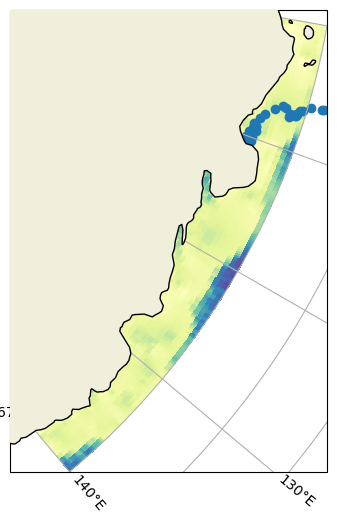

In [25]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax=ax,da=elevation,extent=[minlon,maxlon,minlat,maxlat])
ax.scatter(ds.LONGITUDE, ds.LATITUDE, transform=ccrs.PlateCarree())